In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

from setting_for_sda.path_setting import path_list
from setting_for_sda.date_setting import Date_Setting


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.utils.datetime_handler import calc_rel_period
from lib.visualization.distribution_collector import (calc_top_mid_bottom_tags_prop, compute_proportion_period)
from lib.visualization.plot_generator import PlotGen
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()

import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import spearmanr



Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [2]:
def compute_N_by_week(df, period_col='rel_week', weight_col='tot_pct'):
    """주차별 질문 수 (tot_pct를 질문 수로 쓰는 경우)"""
    N = df.groupby(period_col)[weight_col].sum()
    try:
        N.index = N.index.astype(int)
    except (ValueError, TypeError):
        pass
    return N.sort_index()


In [3]:
dict_ = dict()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    plotgen = PlotGen(idx, 'tag')
    print(f'[Start....] drawing figures for {lang} language')


    df = load_df(plotgen.data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    df = calc_rel_period(df, plotgen.std_date, date_col = 'cdate', period = 7)
    # df_proportion = compute_proportion_period(df,period = 'rel_week', type = 'tag', value_col='pct')

    # N_series = compute_N_by_week(df, weight_col='pct')
    dict_[lang] = compute_N_by_week(df, weight_col='pct')


[Start....] drawing figures for python language
[Start....] drawing figures for javascript language
[Start....] drawing figures for java language
[Start....] drawing figures for c# language
[Start....] drawing figures for c++ language
[Start....] drawing figures for c language
[Start....] drawing figures for r language
[Start....] drawing figures for php language
[Start....] drawing figures for swift language
[Start....] drawing figures for kotlin language
[Start....] drawing figures for dart language
[Start....] drawing figures for typescript language
[Start....] drawing figures for go language
[Start....] drawing figures for ruby language
[Start....] drawing figures for rust language
[Start....] drawing figures for scala language
[Start....] drawing figures for julia language
[Start....] drawing figures for matlab language
[Start....] drawing figures for groovy language
[Start....] drawing figures for objective-c language
[Start....] drawing figures for vb.net language
[Start....] dr

In [4]:
import re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ─────────────────────────────────────
# 1. 패널 데이터 구성
# ─────────────────────────────────────
panel = []
for lang, s in dict_.items():
    g = s.reset_index()
    g.columns = ["rel_week", "n_docs"]
    g["language"] = lang
    panel.append(g)
panel = pd.concat(panel, ignore_index=True)

panel["post"]   = (panel["rel_week"] >= 0).astype(int)
panel["t"]      = panel["rel_week"]
panel["post_t"] = panel["post"] * panel["rel_week"]
panel["log_y"]  = np.log(panel["n_docs"] + 1)

# ─────────────────────────────────────
# 2. 회귀
# ─────────────────────────────────────
formula = ("log_y ~ t + post + post_t "
           "+ C(language) + C(language):post + C(language):post_t")
print(formula)
m = smf.ols(formula, data=panel).fit(
    cov_type="cluster", cov_kwds={"groups": panel["language"]}
)

# ─────────────────────────────────────
# 3. 기준 언어 자동 찾기 (level shift용)
# ─────────────────────────────────────
pat_post = re.compile(r"C\(language\)\[T\.(.+?)\]:post$")
interaction_post = {pat_post.match(n).group(1): v 
                    for n, v in m.params.items() if pat_post.match(n)}

all_langs = list(panel["language"].unique())
baseline_lang = [l for l in all_langs if l not in interaction_post][0]

# 언어별 level effect (참고용)
effects = {baseline_lang: m.params["post"]}
for lang, inter in interaction_post.items():
    effects[lang] = m.params["post"] + inter
eff_series = pd.Series(effects)

# ─────────────────────────────────────
# 4. 언어별 pre-period 평균 (가중치 + summary용)
# ─────────────────────────────────────
pre_size = panel[panel["post"]==0].groupby("language")["n_docs"].mean()
weights  = (pre_size / pre_size.sum()).reindex(eff_series.index)

# ─────────────────────────────────────
# 5. ★ slope change (post_t) 추출 → slope_summary
# ─────────────────────────────────────
pat_post_t = re.compile(r"C\(language\)\[T\.(.+?)\]:post_t$")
interaction_post_t = {pat_post_t.match(n).group(1): v 
                      for n, v in m.params.items() if pat_post_t.match(n)}

# 각 언어의 총 slope change = baseline의 post_t + 해당 언어의 상호작용
slope_effects = {baseline_lang: m.params["post_t"]}
for lang, inter in interaction_post_t.items():
    slope_effects[lang] = m.params["post_t"] + inter

slope_series = pd.Series(slope_effects)

# 가중평균 (질문량 기준)
weighted_slope = (slope_series * weights).sum()

# ─────────────────────────────────────
# 6. slope_summary 데이터프레임 만들기
# ─────────────────────────────────────
slope_summary = pd.DataFrame({
    "slope_change": slope_series,                       # log 단위 추세 변화 (per week)
    "weekly_pct":   (np.exp(slope_series) - 1) * 100,   # 주당 % 변화로 변환
    "pre_avg":      pre_size,                           # 사전 평균 질문 수
}).sort_values("pre_avg", ascending=False)

log_y ~ t + post + post_t + C(language) + C(language):post + C(language):post_t


In [14]:
m.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  log_y   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     139.8
Date:                Tue, 12 May 2026   Prob (F-statistic):           5.29e-52
Time:                        17:17:51   Log-Likelihood:                -118.16
No. Observations:                 239   AIC:                             244.3
Df Residuals:                     235   BIC:                             258.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0527      0.241     16.806      0.000       3.580       4.525
t              0.0118      0.004      2.961      0.003       0.004       0.020
post          -1.1358      0.279     -4.068      0.000      -1.683      -0.589
post_t        -0.0280      0.004     -6.941      0.000      -0.036      -0.020
==============================================================================
Omnibus:                       12.008   Durbin-Watson:                   1.118
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.923
Skew:                          -0.556   Prob(JB):                      0.00156
Kurtosis:                       2.757   Cond. No.                         430.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 8 lags and without small sample correction
"""

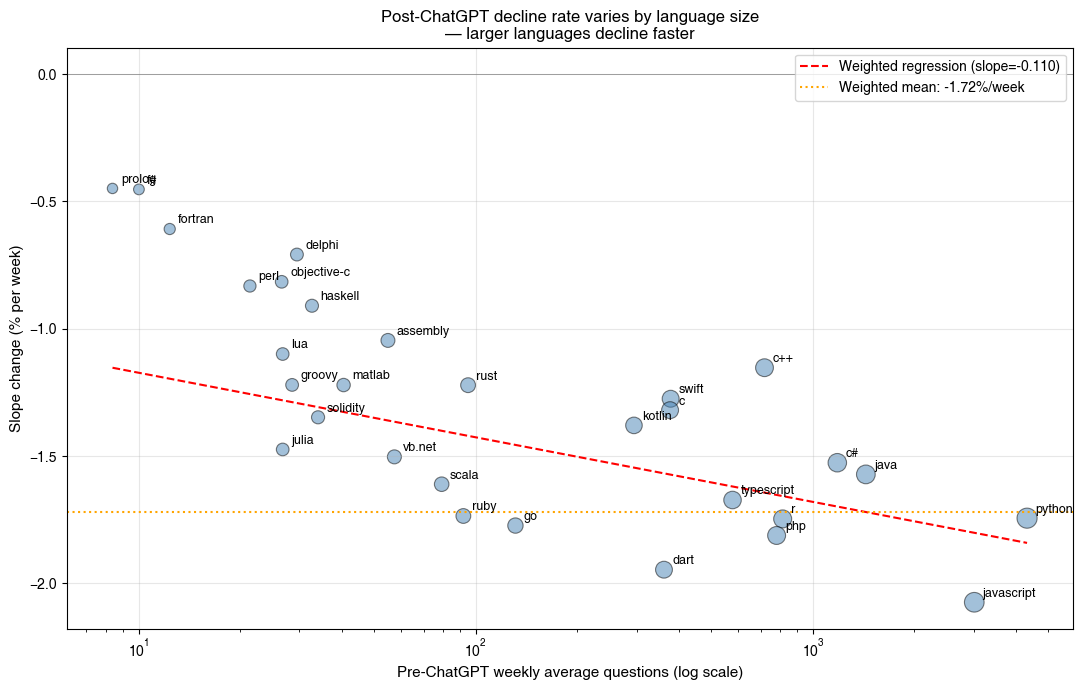

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Scatter plot: language size vs. decline speed
fig, ax = plt.subplots(figsize=(11, 7))

x = slope_summary["pre_avg"]
y = slope_summary["weekly_pct"]  # weekly % change (negative)

# Point sizes proportional to pre_avg for visual weighting
sizes = np.clip(np.log1p(x) * 25, 30, 400)
sc = ax.scatter(x, y, s=sizes, alpha=0.5, 
                color="steelblue", edgecolor="black", linewidth=0.8)

# Labels
for lang, row in slope_summary.iterrows():
    ax.annotate(lang, (row["pre_avg"], row["weekly_pct"]),
                fontsize=9, xytext=(6, 4), textcoords="offset points")

# Weighted regression line
log_x = np.log(x)
coef = np.polyfit(log_x, y, 1, w=x)  # weighted by question volume
xx = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
ax.plot(xx, coef[0]*np.log(xx) + coef[1], "r--", lw=1.5, 
        label=f"Weighted regression (slope={coef[0]:.3f})")

ax.axhline(weighted_slope*100, color="orange", ls=":", lw=1.5,
           label=f"Weighted mean: {weighted_slope*100:.2f}%/week")
ax.axhline(0, color="gray", lw=0.5)

ax.set_xscale("log")
ax.set_xlabel("Pre-ChatGPT weekly average questions (log scale)", fontsize=11)
ax.set_ylabel("Slope change (% per week)", fontsize=11)
ax.set_title("Post-ChatGPT decline rate varies by language size\n"
             "— larger languages decline faster", fontsize=12)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
slope_summary

,slope_change,weekly_pct,pre_avg
python,-0.017592,-1.743803,4319.076923
javascript,-0.020959,-2.074052,3011.576923
java,-0.015843,-1.571858,1436.192308
c#,-0.015378,-1.526080,1181.778846
r,-0.017621,-1.746686,813.634615
php,-0.018284,-1.811793,780.653846
c++,-0.011596,-1.152878,718.701923
typescript,-0.016866,-1.672446,577.701923
swift,-0.012830,-1.274843,378.586538
c,-0.013284,-1.319645,377.067308


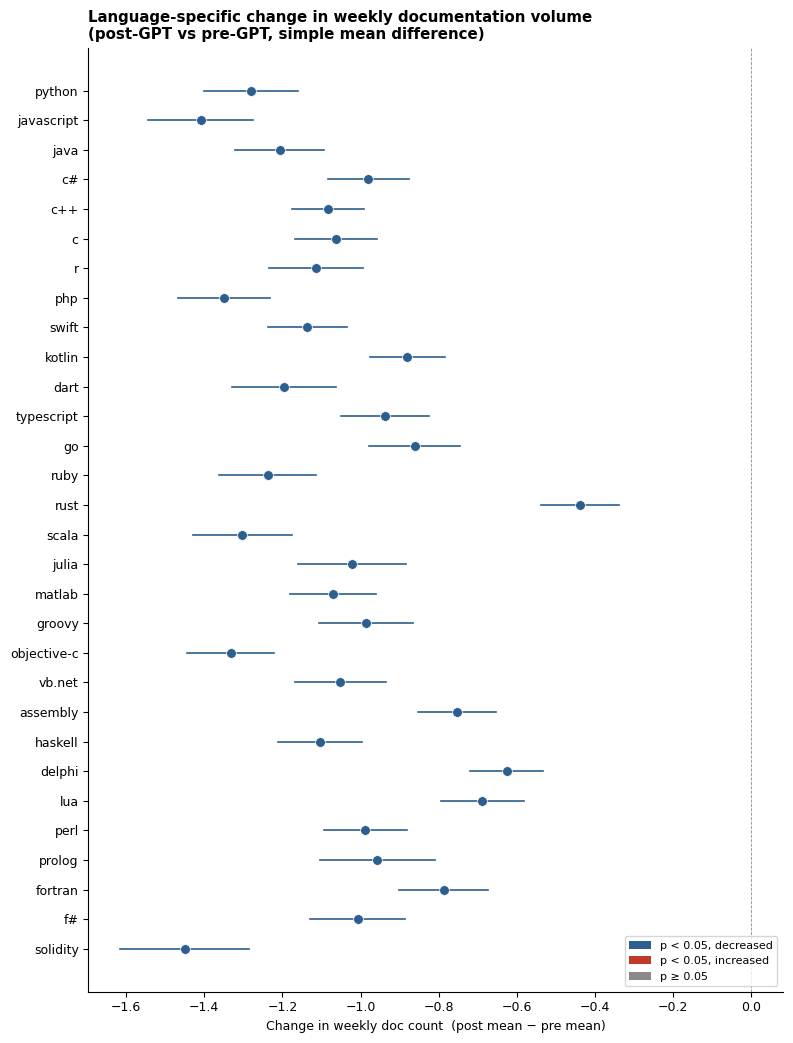

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy import stats

# data = {'solidity': Series(index=rel_week, values=n_docs), ...}

# ─────────────────────────────────────────────────────────
# 1. 언어별 pre/post 평균 차이 + SE + p-value
# ─────────────────────────────────────────────────────────
results = []
for lang, s in dict_.items():
    pre  = s[s.index < 0].values
    post = s[s.index >= 0].values
    if len(pre) < 3 or len(post) < 3:
        continue
    
    # Welch's t-test (분산 다를 수 있으니)
    diff = np.log(post.mean() + 1) - np.log(pre.mean() + 1)
    # SE는 delta method로
    se = np.sqrt(post.var(ddof=1)/(len(post)*(post.mean()+1)**2) +
                pre.var(ddof=1)/(len(pre)*(pre.mean()+1)**2))
    tstat, pval = stats.ttest_ind(post, pre, equal_var=False)
    
    results.append({
        "language":   lang,
        "gpt_effect": diff,        # post 평균 − pre 평균 (주당 문서 수 차이)
        "se":         se,
        "pvalue":     pval,
        "pre_mean":   pre.mean(),
        "post_mean":  post.mean(),
    })

gpt_df = pd.DataFrame(results)
gpt_df["significant"] = gpt_df["pvalue"] < 0.05

# ─────────────────────────────────────────────────────────
# 2. Forest plot
# ─────────────────────────────────────────────────────────
mpl.rcParams.update({"font.family": "sans-serif", "font.size": 9, "axes.linewidth": 0.8})

gpt_sorted = gpt_df.sort_values("gpt_effect").reset_index(drop=True)
n = len(gpt_sorted)

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * n)))

colors = ["#2C5F8D" if r.significant and r.gpt_effect < 0
          else "#C0392B" if r.significant and r.gpt_effect > 0
          else "#8A8A8A"
          for r in gpt_sorted.itertuples()]

lang_order = reversed(list(CONSTANTS.languages_from2020to2022))
gpt_sorted = gpt_df.set_index("language").loc[lang_order].reset_index()
for i, row in gpt_sorted.iterrows():
    lo = row["gpt_effect"] - 1.96 * row["se"]
    hi = row["gpt_effect"] + 1.96 * row["se"]
    ax.plot([lo, hi], [i, i], color=colors[i], lw=1.2)
    ax.plot(row["gpt_effect"], i, "o", color=colors[i],
            markersize=7, markeredgecolor="white", markeredgewidth=0.5)

ax.axvline(0, color="0.55", lw=0.6, ls="--")
ax.set_yticks(range(n))
ax.set_yticklabels(gpt_sorted["language"])
ax.set_xlabel("Change in weekly doc count  (post mean − pre mean)")
ax.set_title("Language-specific change in weekly documentation volume\n"
             "(post-GPT vs pre-GPT, simple mean difference)",
             loc="left", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend = [
    Patch(facecolor="#2C5F8D", label="p < 0.05, decreased"),
    Patch(facecolor="#C0392B", label="p < 0.05, increased"),
    Patch(facecolor="#8A8A8A", label="p ≥ 0.05"),
]
ax.legend(handles=legend, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────
# 1. 언어별 ITS 회귀
# ─────────────────────────────────────────────────────────
results = []
for lang, s in dict_.items():
    g = s.reset_index()
    g.columns = ["rel_week", "n_docs"]
    g = g.sort_values("rel_week").reset_index(drop=True)
    
    g["post"]   = (g["rel_week"] >= 0).astype(int)
    g["t"]      = g["rel_week"]
    g["post_t"] = g["post"] * g["rel_week"]
    g["log_y"]  = np.log(g["n_docs"] + 1)
    
    if len(g) < 30 or g["post"].nunique() < 2:
        continue
    
    X = sm.add_constant(g[["t", "post", "post_t"]])
    m = sm.OLS(g["log_y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 8})
    
    results.append({
        "language":     lang,
        # β₂: 즉각 점프
        "level_shift":  m.params["post"],
        "level_se":     m.bse["post"],
        "level_p":      m.pvalues["post"],
        # β₃: 추세 변화
        "slope_change": m.params["post_t"],
        "slope_se":     m.bse["post_t"],
        "slope_p":      m.pvalues["post_t"],
    })

gpt_df = pd.DataFrame(results)
gpt_df["level_sig"] = gpt_df["level_p"] < 0.05
gpt_df["slope_sig"] = gpt_df["slope_p"] < 0.05

In [8]:
lang_order = reversed(list(CONSTANTS.languages_from2020to2022))
gpt_sorted = gpt_df.set_index("language").loc[lang_order].reset_index()
n = len(gpt_sorted)

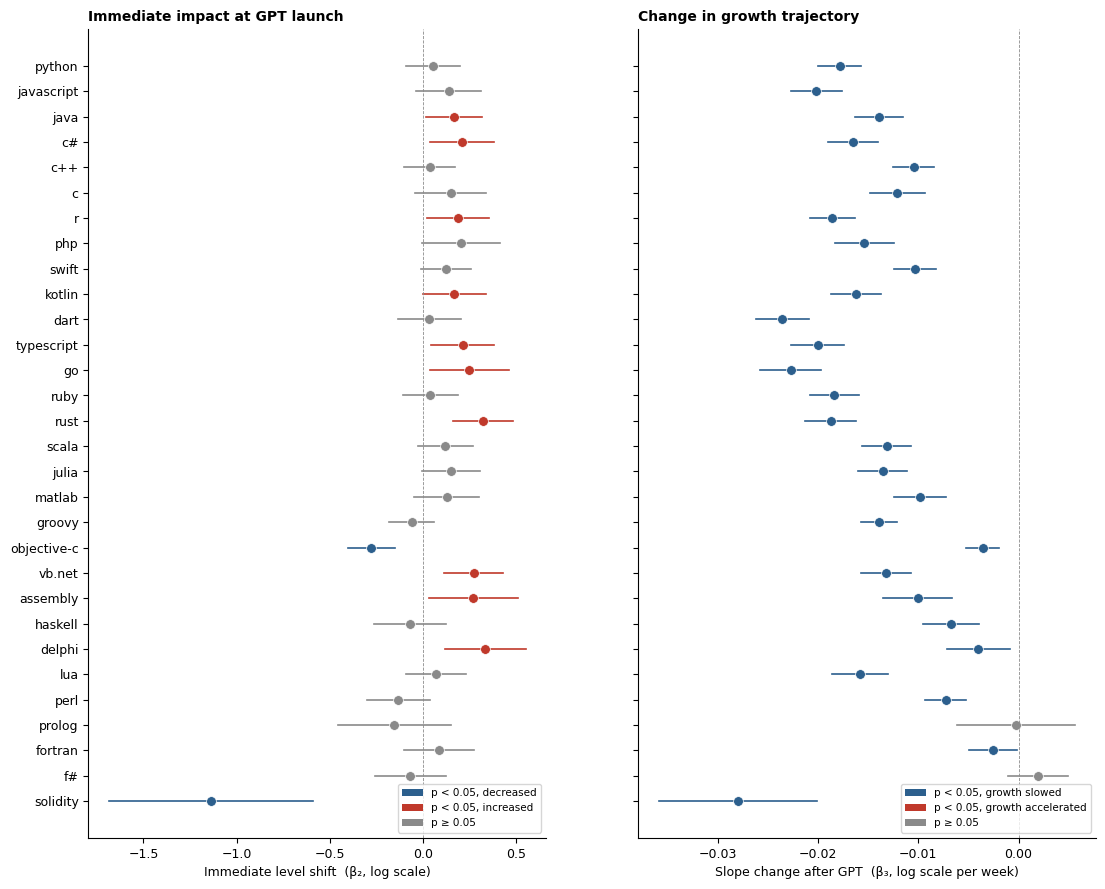

In [9]:

# ─────────────────────────────────────────────────────────
# 3. 두 panel forest plot
# ─────────────────────────────────────────────────────────
mpl.rcParams.update({"font.family": "sans-serif", "font.size": 9, "axes.linewidth": 0.8})

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.35 * n)), sharey=True)

panels = [
    {
        "ax":      axes[0],
        "effect":  "level_shift",
        "se":      "level_se",
        "sig":     "level_sig",
        "xlabel":  "Immediate level shift  (β₂, log scale)",
        "title":   "Immediate impact at GPT launch",
        "neg_lbl": "decreased",
        "pos_lbl": "increased",
    },
    {
        "ax":      axes[1],
        "effect":  "slope_change",
        "se":      "slope_se",
        "sig":     "slope_sig",
        "xlabel":  "Slope change after GPT  (β₃, log scale per week)",
        "title":   "Change in growth trajectory",
        "neg_lbl": "growth slowed",
        "pos_lbl": "growth accelerated",
    },
]

for p in panels:
    ax = p["ax"]
    
    # itertuples + _asdict() 대신 iterrows()
    colors = []
    for _, row in gpt_sorted.iterrows():
        if row[p["sig"]] and row[p["effect"]] < 0:
            colors.append("#2C5F8D")
        elif row[p["sig"]] and row[p["effect"]] > 0:
            colors.append("#C0392B")
        else:
            colors.append("#8A8A8A")
    
    for i, (_, row) in enumerate(gpt_sorted.iterrows()):
        eff = row[p["effect"]]
        se  = row[p["se"]]
        lo  = eff - 1.96 * se
        hi  = eff + 1.96 * se
        ax.plot([lo, hi], [i, i], color=colors[i], lw=1.2)
        ax.plot(eff, i, "o", color=colors[i],
                markersize=7, markeredgecolor="white", markeredgewidth=0.5)
    
    ax.axvline(0, color="0.55", lw=0.6, ls="--")
    ax.set_xlabel(p["xlabel"])
    ax.set_title(p["title"], loc="left", fontweight="bold", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_yticks(range(n))
    ax.set_yticklabels(gpt_sorted["language"])
    legend = [
        Patch(facecolor="#2C5F8D", label=f"p < 0.05, {p['neg_lbl']}"),
        Patch(facecolor="#C0392B", label=f"p < 0.05, {p['pos_lbl']}"),
        Patch(facecolor="#8A8A8A", label="p ≥ 0.05"),
    ]
    ax.legend(handles=legend, loc="lower right", fontsize=7.5)

In [10]:
print(n)

30
